# Neural Networks

## Perceptron

In this first part, we will train a single neuron (a.k.a. perceptron) to classify points in a 2D space. The perceptron learning algorithm is a simple algorithm that updates the weights of the neuron based on the classification errors made on the training data.

We breifly recall this algorihtm below:
1. Initialize the weights of the neuron randomly.
2. For each training sample $(\mathbf{x}_i, y_i)$:
    - Compute the output of the neuron using the current weights.
    $$\hat{y}_i = \begin{cases} 1 & \text{if } \mathbf{w}^\top \mathbf{x}_i > 0 \\ 0 & \text{otherwise} \end{cases}$$
    - Update the weights s.t.:
    $$\mathbf{w} \leftarrow \mathbf{w} + \eta (y_i - \hat{y}_i) \mathbf{x}_i$$
3. Repeat steps 2 and 3 until the weights converge or a maximum number of iterations is reached.

In [ ]:
import numpy as np

def perceptron(X, y, learning_rate=0.1, n_epochs=100, epsilon=1e-6):
    """
    Train a perceptron using the Perceptron learning algorithm.

    Parameters:
    X : numpy array of shape (n_samples, n_features)
        The input data.
    y : numpy array of shape (n_samples,)
        The target labels (0 or 1).
    learning_rate : float
        The learning rate for weight updates.
    n_epochs : int
        The number of epochs to train the perceptron.
    epsilon : float
        The tolerance for convergence. If set to 0, the algorithm will run for the specified number of epochs.

    Returns:
    w : numpy array of shape (n_features,)
        The learned weights of the perceptron.
    b : float
        The learned bias of the perceptron.
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0

    for epoch in range(n_epochs):
        for i in range(n_samples):
            linear_output = np.dot(X[i], w) + b
            y_predicted = 1 if linear_output > 0 else 0

            # Update weights and bias if there is a misclassification
            if y[i] != y_predicted:
                update = learning_rate * (y[i] - y_predicted)
                w += update * X[i]
                b += update
        # Check for convergence
        if epsilon > 0 :
            errors = np.sum(y != (np.dot(X, w) + b > 0).astype(int))
            print(errors)
            if errors / n_samples < epsilon:
                break
    return w, b

Now, for testing the perceptron learning algorithm, we will generate a synthetic dataset of points in a 2D space. The points will be labeled according to their position relative to a line (the decision boundary). The goal is to train the perceptron to correctly classify the points based on their labels. We will first generate the dataset and visualize it, then we will implement the perceptron learning algorithm and train the perceptron on the dataset for one epoch only. An epoch is defined as a single pass through the entire training dataset. After training, we will visualize the decision boundary learned by the perceptron and evaluate its performance on the training data.

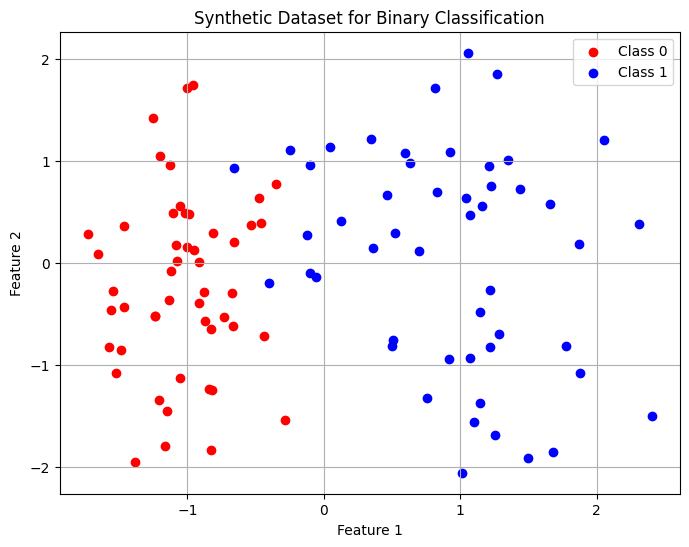

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_features=2, n_redundant=0, n_informative=1, n_clusters_per_class=1, random_state=7)

# plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')
plt.title('Synthetic Dataset for Binary Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

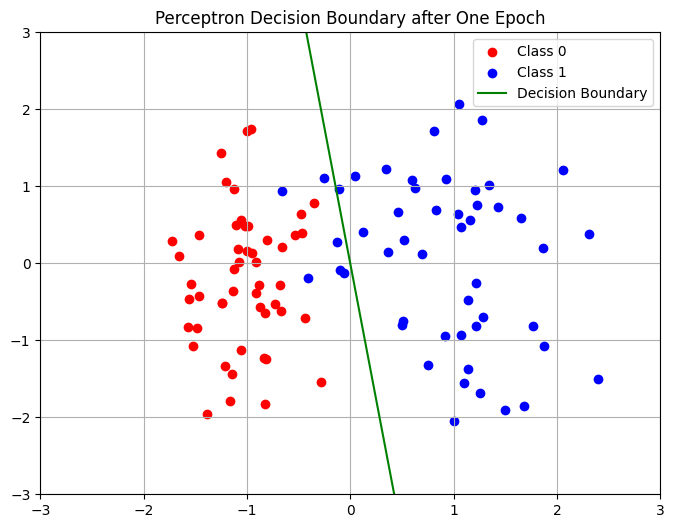

In [3]:
# train the perceptron for one epoch and plot the decision boundary
w, b = perceptron(X, y, learning_rate=0.1, n_epochs=1, epsilon=1e-6)

# plot the decision boundary
plt.figure(figsize=(8, 6))
# Plot the dataset
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')
# Plot the decision boundary
x_values = np.linspace(-1, 1, 100)
y_values = -(w[0] * x_values + b) / w[1]
plt.plot(x_values, y_values, color='green', label='Decision Boundary')
plt.title('Perceptron Decision Boundary after One Epoch')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.grid()
plt.show()

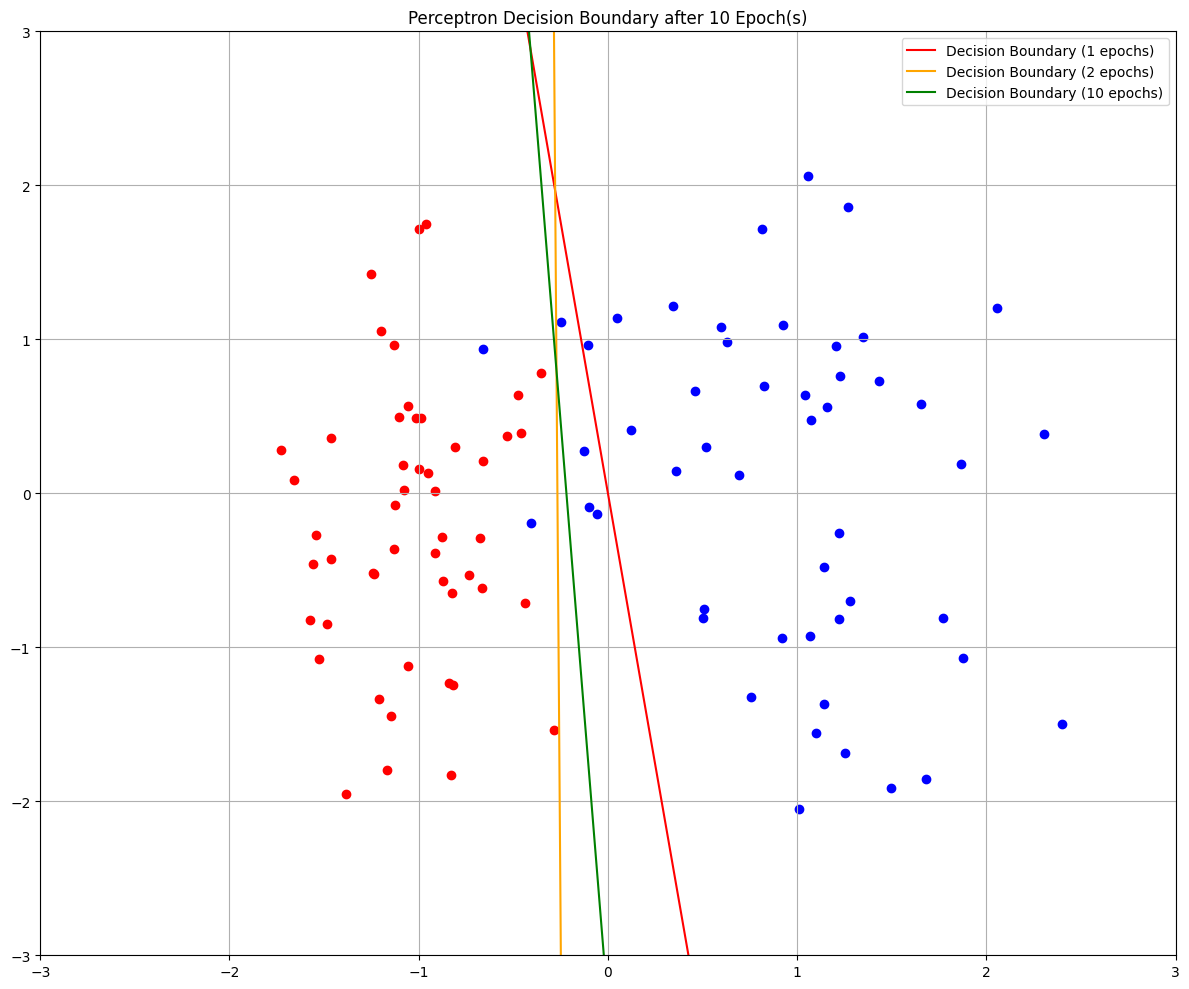

In [4]:
# Do the same with 1, 2, 5 and 10 epochs and plot the decision boundary of the four resulting models on the same figure
colors = ['red', 'orange', 'green']
epochs_list = [1, 2, 10]
plt.figure(figsize=(12, 10))
# Plot the dataset
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue')
for i, n_epochs in enumerate(epochs_list):
    w, b = perceptron(X, y, learning_rate=0.1, n_epochs=n_epochs, epsilon=1e-6)
    # plt.subplot(2, 2, i + 1)
    # Plot the decision boundary
    x_values = np.linspace(-1, 1, 100)
    y_values = -(w[0] * x_values + b) / w[1]
    plt.plot(x_values, y_values, color=colors[i], label=f'Decision Boundary ({n_epochs} epochs)')
plt.title(f'Perceptron Decision Boundary after {n_epochs} Epoch(s)')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
